In [2]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

# 1. Lees de CSV in met pandas
# Pas evt. de separator aan (bijv. sep=';') als je bestand dat gebruikt
df_bomen = pd.read_csv("data/bomen-stamgegevens.csv")

# 2. Functie om de string "SRID=28992;POINT (...)" om te zetten naar geometrie
def parse_ewkt(text):
    if pd.isna(text) or text == "":
        return None
    # Split op de puntkomma en pak het tweede deel (de pure WKT string)
    wkt_string = text.split(';')[-1]
    return wkt.loads(wkt_string)

# Pas de functie toe op de kolom "geometrie"
df_bomen['geometry_object'] = df_bomen['geometrie'].apply(parse_ewkt)

# 3. Maak er een GeoDataFrame van
bomen = gpd.GeoDataFrame(df_bomen, geometry='geometry_object')

# Zet het coördinatensysteem (CRS) vast op RD New
bomen = bomen.set_crs(epsg=28992)

# 4. Laad de wijken (jouw code)
wijken = gpd.read_file("data/alleen_wijken.gpkg")
if wijken.crs is None:
    wijken = wijken.set_crs(epsg=28992)

# 5. De match maken (Spatial Join)
# Dit voegt de kolommen van 'wijken' toe aan de bomen
resultaat = gpd.sjoin(bomen, wijken, how="left", predicate="within")

# 6. Resultaat opslaan of bekijken
print(resultaat.head())

# Optioneel: opslaan als nieuw bestand (bijvoorbeeld GeoPackage of CSV)
# Voor CSV moet je de geometrie kolom vaak weer droppen of naar string omzetten
# resultaat.drop(columns='geometry_object').to_csv("bomen_met_wijken.csv", index=False)

       id    gbdBuurtId                                          geometrie  \
0  919933  3.630980e+12                SRID=28992;POINT (122115.11 483653)   
1  919934  3.630980e+12  SRID=28992;POINT (121980.147653773 483685.1651...   
2  919935  3.630980e+12             SRID=28992;POINT (118737.81 482805.51)   
3  919936  3.630980e+12  SRID=28992;POINT (122054.562595115 484656.7312...   
4  919937  3.630980e+12             SRID=28992;POINT (120154.43 483804.66)   

  boomhoogteklasseActueel    typeEigenaarPlus  jaarVanAanleg  \
0         e. 15 tot 18 m.  Gemeente Amsterdam         1948.0   
1          c. 9 tot 12 m.  Gemeente Amsterdam         1978.0   
2          c. 9 tot 12 m.  Gemeente Amsterdam         1990.0   
3           b. 6 tot 9 m.  Gemeente Amsterdam         2002.0   
4           b. 6 tot 9 m.  Gemeente Amsterdam         1985.0   

                               soortnaam          standplaats  \
0                        Tilia americana          Groenobject   
1              U

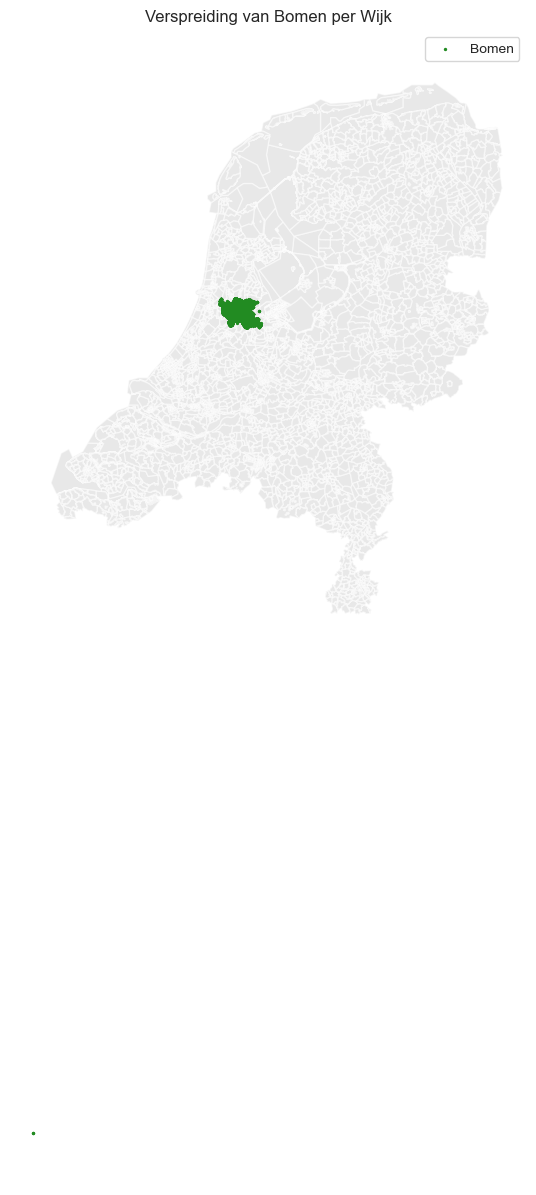

In [3]:
import matplotlib.pyplot as plt

# Maak een figuur aan (figsize bepaalt de grootte in inches)
fig, ax = plt.subplots(figsize=(15, 15))

# 1. Teken eerst de wijken als achtergrond
# 'alpha' maakt de vlakken iets doorzichtig
wijken.plot(ax=ax, color='lightgrey', edgecolor='white', alpha=0.5)

# 2. Teken de bomen eroverheen
# We gebruiken 'markersize=1' omdat het er waarschijnlijk veel zijn
resultaat.plot(ax=ax, color='forestgreen', markersize=2, label='Bomen')

# Opmaak
ax.set_title("Verspreiding van Bomen per Wijk")
ax.set_axis_off() # Haal de assen met coördinaten weg voor een schoner beeld
plt.legend()

# Toon de kaart
plt.show()

In [4]:
# Even checken hoe de kolom heet (vaak 'GM_NAAM' of 'gemeentenaam')
# print(wijken.columns)

# We maken een nieuwe variabele die alleen Amsterdam bevat
# Let op: pas 'GM_NAAM' aan als jouw kolom 'gemeentenaam' heet
amsterdam_wijken = wijken[wijken['GM_NAAM'] == 'Amsterdam']

# Optioneel: Filter ook de bomen (zodat je die ene boom links onderin kwijt bent)
# We gebruiken hier het resultaat van je spatial join
bomen_amsterdam = resultaat[resultaat['GM_NAAM'] == 'Amsterdam']

KeyError: 'GM_NAAM'